# Day 3 (R parallel): density regressions and implications for Morocco

This is the R companion to the Day 3 Python notebook. Continuing from yesterday - density ranks how near each product sits to a country's basket, and whether nearby products actually get entered is an empirical question. We compute density from an earlier year so that it is measured before the outcome, fit the cross-section, mark which products each country entered since then, and run the entry, exit, and growth regressions. Then we run the same test at the country level, whether complexity predicts growth. The measures come from `economiccomplexity` on the continuous M-hat, exactly as on Day 2, and the regressions come from `fixest`, with tables from `modelsummary`.

`COUNTRY`, `COMPARATORS`, and the years at the top drive every result. Edit them to point the notebook at your own country.

## 0. Setup

Same packet as Days 1 and 2, nothing new to download. Two tools join the Day 2 stack: `fixest` runs the fixed-effects regressions and `modelsummary` renders them as tables. The setup cell installs anything missing and downloads the packet on first run, so it works on Colab's R runtime as well as locally.

In [1]:
# On Colab's Linux runtime, CRAN packages compile from source, which is slow.
# Posit's public package manager serves prebuilt Linux binaries of the same
# CRAN packages, so on Linux we install from there. Mac and Windows already get
# binaries from the regular CRAN mirror, so they keep it.
needed <- setdiff(
  c("economiccomplexity", "arrow", "dplyr", "fixest", "modelsummary", "gt", "ggplot2"),
  rownames(installed.packages())
)
if (length(needed) > 0) {
  if (Sys.info()[["sysname"]] == "Linux") {
    codename <- system(". /etc/os-release && echo $VERSION_CODENAME", intern = TRUE)
    options(
      repos = c(CRAN = paste0(
        "https://packagemanager.posit.co/cran/__linux__/", codename, "/latest"
      )),
      HTTPUserAgent = sprintf(
        "R/%s R (%s)", getRversion(),
        paste(getRversion(), R.version$platform, R.version$arch, R.version$os)
      )
    )
  }
  install.packages(needed)
}
suppressMessages({
  library(arrow) # read the packet's .parquet files
  library(dplyr) # filter, select, group, summarise
  library(economiccomplexity) # complexity_measures(), proximity(), density()
  library(fixest) # feols() for the entry, exit, growth, and growth regressions
  library(modelsummary) # regression tables
  library(ggplot2) # the decile bar chart
})

# --- The ONE place you edit to make this notebook about your own country. ------
# Codes are ISO 3166-1 alpha-2 (two letters). MA = Morocco, EG = Egypt,
# TN = Tunisia, KR = Republic of Korea. See reference/units.csv.
COUNTRY <- "MA" # the focus country (Morocco)
COMPARATORS <- c("EG", "TN", "KR") # Egypt, Tunisia (MENA) + Korea (frontier)
YEAR_T0 <- 2012 # density is measured here, BEFORE the outcome
YEAR_T1 <- 2023 # entries and exits are observed here
YEAR_EARLY <- 2001 # start of the first growth window in section 9
# -------------------------------------------------------------------------------

# Resolve the data packet: the course repository's copy when it exists, and
# otherwise (Colab included) a one-time download of the two archives this
# notebook needs, the same source the Python notebooks use.
PACKET <- normalizePath(
  file.path("..", "..", "data", "processed", "morocco_data_packet"),
  mustWork = FALSE
)
DATA_RELEASE <- "https://github.com/shreyasgm/ecu-complexity-labs/releases/download/data-v1"
if (!dir.exists(PACKET)) {
  PACKET <- normalizePath("morocco_data_packet", mustWork = FALSE)
  options(timeout = max(600, getOption("timeout"))) # exports.zip is about 45 MB
  for (folder in c("exports", "reference")) {
    if (!dir.exists(file.path(PACKET, folder))) {
      cat("Downloading", paste0(folder, ".zip"), "from the course data release ...\n")
      zf <- tempfile(fileext = ".zip")
      download.file(paste0(DATA_RELEASE, "/", folder, ".zip"), zf, mode = "wb", quiet = TRUE)
      unzip(zf, exdir = PACKET)
      unlink(zf)
    }
  }
}

# Fail loud on anything missing, naming the exact file.
required <- c(
  file.path(PACKET, "exports", "outputs.parquet"),
  file.path(PACKET, "reference", "fields.csv"),
  file.path(PACKET, "reference", "units.csv")
)
missing <- required[!file.exists(required)]
if (length(missing) > 0) {
  stop(
    "Required packet file(s) not found:\n  ", paste(missing, collapse = "\n  "), "\n",
    "Delete the morocco_data_packet folder and re-run this cell to retry the download."
  )
}
cat("Packet found:", PACKET, "\n")
cat("Focus country:", COUNTRY, "| window:", YEAR_T0, "->", YEAR_T1, "\n")

Packet found: /Users/shg309/Library/CloudStorage/Dropbox-Personal/Education/hks_cid_growth_lab/misc/morocco_summer_school/data/processed/morocco_data_packet 


Focus country: MA | window: 2012 -> 2023 


In [2]:
# The three packet tables Day 3 needs. We keep the reference column names with
# spaces intact so the codes line up with the packet.
exports <- read_parquet(file.path(PACKET, "exports", "outputs.parquet"))
fields <- read.csv(
  file.path(PACKET, "reference", "fields.csv"),
  check.names = FALSE, stringsAsFactors = FALSE
)
units <- read.csv(
  file.path(PACKET, "reference", "units.csv"),
  check.names = FALSE, stringsAsFactors = FALSE
)
prod_name <- setNames(fields$`Field Name`, fields$`Field ID`)
cat("years in packet:", paste(range(exports$Period), collapse = " to "), "\n")

years in packet: 2001 to 2023 


## 1. Compute complexity metrics in a function

Today we need the whole Day 2 pipeline at several points in time, so we wrap it in a function of the year. It builds the export matrix, drops the all-zero rows and columns, computes RCA and the continuous M-hat, and hands M-hat to `economiccomplexity` for every measure. The one lesson yesterday taught us stays in the code: the continuous M-hat is the presence matrix, so the package runs on it directly, and the binary Mcp (RCA > 1) survives only to mark baskets and to count entries and exits.

In [3]:
complexity_for_year <- function(year) {
  year_long <- exports %>%
    filter(Period == year) %>%
    select(Unit, `Field ID`, Outputs)
  # Pivot to a country x product matrix, filling absent combinations with zero.
  X <- tapply(year_long$Outputs, list(year_long$Unit, year_long$`Field ID`), sum)
  X[is.na(X)] <- 0
  # Early years have a few countries or products with zero recorded trade; drop
  # them, computing both masks on the original matrix so the drop matches Python.
  keep_r <- rowSums(X) > 0
  keep_c <- colSums(X) > 0
  X <- X[keep_r, keep_c, drop = FALSE]
  shares <- X / rowSums(X)
  world_share <- colSums(X) / sum(X)
  rca <- sweep(shares, 2, world_share, "/")
  mcp <- (rca > 1) * 1.0 # the binary basket, for events and highlights
  m_hat <- rca / (1 + rca) # the continuous presence matrix, for the measures
  # Every measure from the continuous matrix, as on Day 2. The messages the
  # package prints about sign correction are informational, so we quiet them.
  suppressMessages({
    cm <- complexity_measures(m_hat, method = "eigenvalues")
    prox <- proximity(m_hat, compute = "product")
    diag(prox$proximity_product) <- 0 # drop self-proximity before density()
    dens <- as.matrix(economiccomplexity::density(m_hat, prox$proximity_product))
    # complexity_outlook() rejects a Matrix, so pass the base matrix phi.
    outlook <- complexity_outlook(m_hat, as.matrix(prox$proximity_product), cm$complexity_index_product)
  })
  list(
    year = year, X = X, rca = rca, mcp = mcp, m_hat = m_hat, density = dens,
    eci = cm$complexity_index_country, pci = cm$complexity_index_product,
    coi = outlook$complexity_outlook_index
  )
}

res_t1 <- complexity_for_year(YEAR_T1)
diversity_t1 <- rowSums(res_t1$mcp)
cat(COUNTRY, "diversity in", YEAR_T1, ":", diversity_t1[COUNTRY], "\n")

# Self-check: the Day 2 handshake. Same data and method must give yesterday's
# numbers: diversity 129, and density inside the basket above density outside.
dens_ma <- res_t1$density[COUNTRY, ]
in_b <- mean(dens_ma[res_t1$mcp[COUNTRY, ] == 1])
out_b <- mean(dens_ma[res_t1$mcp[COUNTRY, ] == 0])
if (diversity_t1[COUNTRY] != 129) stop("Morocco's 2023 diversity is ", diversity_t1[COUNTRY], " but must be 129.")
if (!(in_b > out_b)) stop("density inside the basket must exceed density outside it.")
if (abs(in_b - 0.220) > 0.015 || abs(out_b - 0.187) > 0.015) {
  stop("in/out density should reproduce 0.220 and 0.187, got ", round(in_b, 3), " and ", round(out_b, 3), ".")
}
cat(sprintf("OK: pipeline reproduced (%.3f in-basket vs %.3f outside).\n", in_b, out_b))

MA diversity in 2023 : 129 


OK: pipeline reproduced (0.220 in-basket vs 0.187 outside).


## 2. Rewind to the earlier year

A prediction has to be made before the outcome. If we scored products by density today and then checked which are in today's basket, that would be circular. So the pipeline runs again for an earlier year, and every predictor comes from there. We align the two years on the countries and products present in both, so every comparison below is cell for cell.

In [4]:
res_t0 <- complexity_for_year(YEAR_T0)

common_c <- intersect(rownames(res_t0$rca), rownames(res_t1$rca))
common_p <- intersect(colnames(res_t0$rca), colnames(res_t1$rca))
mcp0 <- res_t0$mcp[common_c, common_p] > 0
mcp1 <- res_t1$mcp[common_c, common_p] > 0

# One index grid over the aligned cells, reused to stack every matrix into the
# same country-product order below.
idx <- as.matrix(expand.grid(ci = seq_along(common_c), pi = seq_along(common_p)))
cell_loc <- common_c[idx[, 1]]
cell_prod <- common_p[idx[, 2]]

cat("aligned:", length(common_c), "countries x", length(common_p), "products\n")
cat(
  COUNTRY, "diversity:", sum(mcp0[COUNTRY, ]), "in", YEAR_T0,
  "->", sum(mcp1[COUNTRY, ]), "in", YEAR_T1, "\n"
)

# Which of the country's ten biggest current exports were not competitive at t0?
top_now <- sort(res_t1$X[COUNTRY, common_p], decreasing = TRUE)[1:10]
was_out <- prod_name[names(top_now)[!mcp0[COUNTRY, names(top_now)]]]
cat("top-10", YEAR_T1, "exports with no RCA in", YEAR_T0, ":", paste(was_out, collapse = ", "), "\n")

# Self-check: the alignment kept the world intact.
if (!(length(common_c) > 150 && length(common_p) > 800)) stop("the aligned matrices lost too many countries or products.")
if (!all(dim(mcp0) == dim(mcp1))) stop("the two years must be aligned to the same shape.")
cat("OK: both years aligned cell for cell.\n")

aligned: 191 countries x 862 products


MA diversity: 139 in 2012 -> 129 in 2023 


top-10 2023 exports with no RCA in 2012 : Vehicle Parts 


OK: both years aligned cell for cell.


## 3. The cross-section: density fits the world as it is

Before asking whether density predicts change, the morning's two-stage approach asks a simpler question first: how much of the world's export pattern, as it stands, does density explain? This is the cross-sectional regression from Lecture 5, run on one year: the log of RCA against the log of relatedness density - each row is one country and product with positive exports. We stay with the product space density you built yesterday, which carries most of the fit on its own.

In [5]:
rca0 <- res_t0$rca[common_c, common_p]
ps_density <- res_t0$density[common_c, common_p]

# The cross-section frame: one row per cell with positive exports, both variables
# in logs as in the lecture's table.
pos <- rca0[idx] > 0
cs_frame <- data.frame(
  loc = cell_loc[pos],
  log_rca = log(rca0[idx][pos]),
  log_ps = log(ps_density[idx][pos])
)
cat(format(nrow(cs_frame), big.mark = ","), "country-product cells with positive exports in", YEAR_T0, "\n")

112,396 country-product cells with positive exports in 2012 


In [6]:
m_cross <- feols(log_rca ~ log_ps, data = cs_frame, cluster = ~loc)
modelsummary(
  list("RCA (log), 2012" = m_cross),
  output = "gt", stars = TRUE, gof_omit = "AIC|BIC|Log|RMSE|Std",
  coef_map = c("log_ps" = "Product space density (log)", "(Intercept)" = "Constant"),
  notes = "Cross-section of country-product cells with positive exports. Standard errors clustered by country."
) |>
  gt::as_raw_html() |>
  IRdisplay::display_html()

"+ p < 0.1, * p < 0.05, ** p < 0.01, *** p < 0.001"
Cross-section of country-product cells with positive exports. Standard errors clustered by country.


In [7]:
# The elasticity is the slope on log density; the log-log form reads it as the
# percent change in RCA for a one percent change in density.
b_slope <- coef(m_cross)["log_ps"]
cat(sprintf("elasticity (slope) %.2f, constant %.2f, R2 %.2f from density alone.\n",
  b_slope, coef(m_cross)["(Intercept)"], r2(m_cross, "r2")))

# Self-check: the lecture's qualitative pattern, not its numbers.
if (!(b_slope > 0)) stop("density must relate positively to RCA in the cross-section.")
if (!(abs(coef(m_cross)["log_ps"] / se(m_cross)["log_ps"]) > 5)) stop("the cross-sectional fit should be precisely estimated.")
if (!(r2(m_cross, "r2") > 0.1)) stop("density alone should explain a visible share of the cross-section.")
cat("OK: density explains a visible share of who exports what before any fixed effect.\n")

elasticity (slope) 1.56, constant 0.57, R2 0.25 from density alone.


OK: density explains a visible share of who exports what before any fixed effect.


Density explains a visible share of who exports what, before any fixed effect and with only revealed co-location as input, which is why the lecture treats it as a summary of a country's productive ecosystem. This regression cannot answer the question we actually care about, because in a single year density and RCA are two views of the same matrix. The real test is dynamic, and everything that follows sets it up.

## 4. Mark entries and exits

An entry is a product the country did not export competitively at the start of the window but does at the end. Exits are the mirror image, and they matter just as much: baskets churn, and a serious analysis counts both directions.

There are many ways to mark entries and exits, but this is the most intuitive: a cell is an entry when the country was NOT in the product at the start of the window but is in it at the end. In practice, you would have a more sophisticated definition.

In [8]:
appeared <- !mcp0 & mcp1
exited <- mcp0 & !mcp1

n_candidates <- sum(!mcp0)
n_incumbents <- sum(mcp0)
entry_rate <- sum(appeared) / n_candidates
exit_rate <- sum(exited) / n_incumbents
cat("candidate cells (no RCA at", YEAR_T0, "):", format(n_candidates, big.mark = ","), "\n")
cat("entries:", format(sum(appeared), big.mark = ","), sprintf("(%.1f%% of candidates)\n", 100 * entry_rate))
cat("exits:  ", format(sum(exited), big.mark = ","), sprintf("(%.1f%% of incumbents)\n", 100 * exit_rate))
cat(COUNTRY, ":", sum(appeared[COUNTRY, ]), "entries,", sum(exited[COUNTRY, ]), "exits\n")

# Self-check: the event definitions must be internally consistent.
if (any(appeared & mcp0)) stop("an entry cannot happen in a product the country already exported at t0.")
if (any(appeared & exited)) stop("no cell can be both an entry and an exit.")
if (!(entry_rate > 0.01 && entry_rate < 0.15)) stop("the pooled entry rate should be a few percent, got ", round(entry_rate, 3), ".")
if (!(exit_rate > 0.1 && exit_rate < 0.6)) stop("the pooled exit rate should be substantial, got ", round(exit_rate, 3), ".")
cat("OK: entries and exits marked consistently.\n")

candidate cells (no RCA at 2012 ): 142,651 


entries: 6,900 (4.8% of candidates)


exits:   7,537 (34.3% of incumbents)


MA : 33 entries, 43 exits


OK: entries and exits marked consistently.


Keep that exit rate in mind. Roughly a third of the products a country exports competitively in one year are gone from its basket eleven years later. Comparative advantage is a moving target, which is exactly why a static opportunity list is not enough and we need to know what predicts the movement.

## 5. Test table

We assemble everything into one regression table: one row per aligned country and product, with the outcome events and the density score. Density comes from `YEAR_T0`, the year before any of the outcomes happened. Measuring density in the outcome year would bake the answer into the question, since entering a product mechanically raises the density around it, so the lag is the whole point.

In [9]:
X0a <- res_t0$X[common_c, common_p]
X1a <- res_t1$X[common_c, common_p]
dens_t0 <- res_t0$density[common_c, common_p]
frame <- data.frame(
  loc = cell_loc, prod = cell_prod,
  incumbent = as.integer(mcp0[idx]),
  appeared = as.integer(appeared[idx]),
  exited = as.integer(exited[idx]),
  x0 = X0a[idx], x1 = X1a[idx],
  density = dens_t0[idx],
  stringsAsFactors = FALSE
)
# Standardize once so every coefficient below reads "per one standard deviation
# of density". The mean and sd come from the full aligned frame, all cells.
frame$density_sd <- (frame$density - mean(frame$density)) / sd(frame$density)
cat("frame rows:", format(nrow(frame), big.mark = ","), "| density mean",
  round(mean(frame$density), 3), "sd", round(sd(frame$density), 3), "\n")
head(frame[, c("loc", "prod", "incumbent", "appeared", "exited", "density", "density_sd")], 3)

# Self-check: the predictor predates the outcome, and no value went missing.
if (any(is.na(frame$density))) stop("every aligned cell should have a t0 density.")
cat("OK: density measured in", YEAR_T0, ", outcomes measured in", YEAR_T1, ".\n")

frame rows: 164,642 | density mean 0.17 sd 0.126 


,loc,prod,incumbent,appeared,exited,density,density_sd
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>
1,AD,P - 0101,0,1,0,0.17516522,0.03866099
2,AE,P - 0101,0,0,0,0.21837049,0.38175749
3,AF,P - 0101,0,0,0,0.08680074,-0.66304832


OK: density measured in 2012 , outcomes measured in 2023 .


## 6. The Principle of Relatedness

The morning quoted the stylized fact: economies diversify preferentially into activities related to what they already do. Before any regression, look at it raw. We split the candidate products (no RCA at t0) into ten equal groups by their t0 density and compute the share of each group that had been entered by t1.

In [10]:
cand <- frame[frame$incumbent == 0, ]
# Decile edges from type-7 quantiles, which is the interpolation pandas qcut uses,
# so the ten groups match the Python notebook cell for cell.
edges <- quantile(cand$density, probs = seq(0, 1, 0.1), type = 7)
cand$decile <- cut(cand$density, breaks = edges, include.lowest = TRUE, labels = FALSE) # 1 = least related
entry_by_decile <- tapply(cand$appeared, cand$decile, mean)

ratio <- entry_by_decile[10] / entry_by_decile[1]
print(round(entry_by_decile * 100, 2))
cat(sprintf("top decile / bottom decile = %.1fx\n", ratio))

    1     2     3     4     5     6     7     8     9    10 
 0.89  1.51  2.47  3.73  4.63  6.13  4.30  6.17  7.29 11.25 


top decile / bottom decile = 12.6x


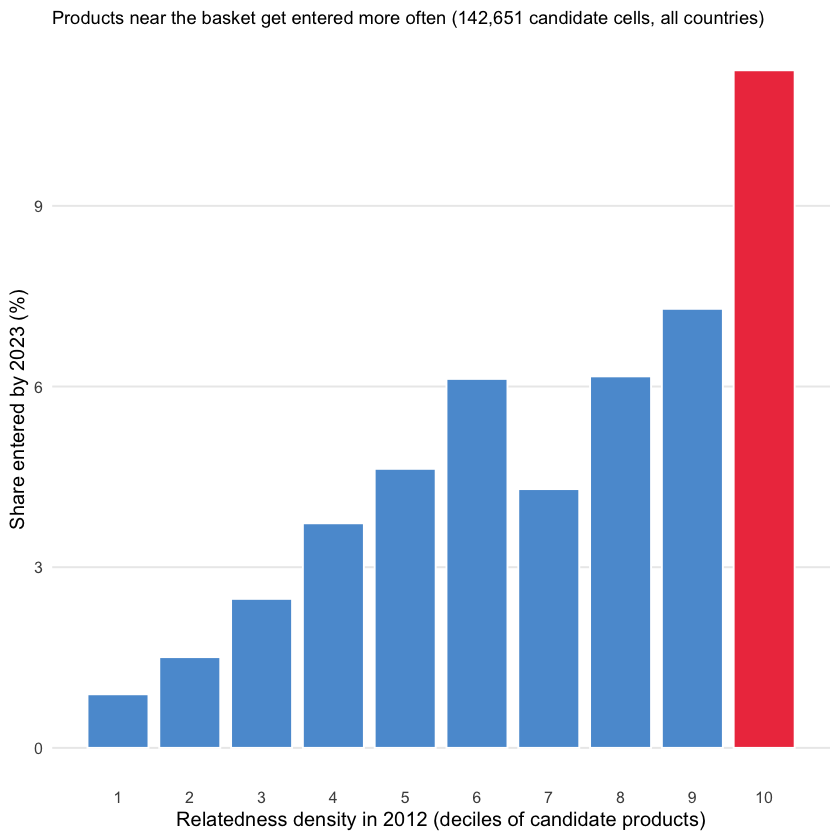

In [11]:
bar_df <- data.frame(
  decile = as.integer(names(entry_by_decile)),
  rate = as.numeric(entry_by_decile) * 100
)
bar_df$top <- bar_df$decile == 10 # highlight the top decile in Atlas red
ggplot(bar_df, aes(x = decile, y = rate, fill = top)) +
  geom_col(color = "white", width = 0.85) +
  scale_fill_manual(values = c("FALSE" = "#5b9bd5", "TRUE" = "#ee3e4c"), guide = "none") +
  scale_x_continuous(breaks = 1:10) +
  labs(
    x = paste0("Relatedness density in ", YEAR_T0, " (deciles of candidate products)"),
    y = paste0("Share entered by ", YEAR_T1, " (%)"),
    title = paste0(
      "Products near the basket get entered more often (",
      format(nrow(cand), big.mark = ","), " candidate cells, all countries)"
    )
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    plot.title = element_text(size = 11, hjust = 0)
  )

In [12]:
# Self-check: the gradient the principle predicts.
if (length(entry_by_decile) != 10) stop("ten deciles in, ten entry rates out.")
if (!(entry_by_decile[10] > 2 * entry_by_decile[1])) stop("the top density decile should be entered at least twice as often as the bottom one.")
rho_dec <- cor(seq_along(entry_by_decile), entry_by_decile, method = "spearman")
if (!(rho_dec > 0.7)) stop("entry rates should rise with the density decile, Spearman ", round(rho_dec, 2), ".")
cat(sprintf("OK: entry rises with density (%.1fx from bottom to top decile).\n", ratio))

OK: entry rises with density (12.6x from bottom to top decile).


This is the same figure the Principle of Relatedness literature shows for products, industries, technologies, and research areas, drawn from your own pipeline. The gradient is real, and it is also not yet a regression: rich diversified countries enter more products everywhere, and popular products get entered by everyone. The next section accounts for both.

## 7. Density regressions

The bar chart pools everything, so part of its gradient could just be that diversified countries enter more and common products attract everyone. The fix is fixed effects. A country fixed effect absorbs everything constant about the country in this window, and a product fixed effect absorbs everything constant about the product. What survives is within-country, within-product variation: does this country enter this product more often when the product sits closer to its basket than the country's overall entry activity and the product's overall popularity would predict?

We run four regressions on the same table. Entry appears twice, once pooled (no fixed effects, so it is the bar chart in one number) and once within (both fixed effects on), with no control for the initial export level, since a product the country does not yet make has no meaningful starting value. Exit and export growth carry both fixed effects and that initial-level control, growth on the intensive margin for cells that already exported something at t0, transformed with asinh, which behaves like a log but tolerates a collapse to zero. The entry and exit columns are linear probability models; note that in practice, you would use logit / probit models. Standard errors are clustered by country.

In [13]:
# Growth on the intensive margin: the asinh difference tolerates x1 = 0, unlike
# log growth. We control for the initial level, the usual convergence term.
frame$growth_ihs <- asinh(frame$x1) - asinh(frame$x0)
frame$ihs_x0 <- asinh(frame$x0)

m_entry_pooled <- feols(appeared ~ density_sd, data = subset(frame, incumbent == 0), cluster = ~loc)
m_entry <- feols(appeared ~ density_sd | loc + prod, data = subset(frame, incumbent == 0), cluster = ~loc)
m_exit <- feols(exited ~ density_sd + ihs_x0 | loc + prod, data = subset(frame, incumbent == 1), cluster = ~loc)
m_growth <- feols(growth_ihs ~ density_sd + ihs_x0 | loc + prod, data = subset(frame, x0 > 0), cluster = ~loc)

modelsummary(
  list(
    "Entered (pooled)" = m_entry_pooled,
    "Entered" = m_entry,
    "Exited" = m_exit,
    "Export growth (asinh)" = m_growth
  ),
  output = "gt", stars = TRUE, gof_omit = "AIC|BIC|Log|RMSE|Std",
  coef_map = c(
    "density_sd" = sprintf("Relatedness density, %d (sd)", YEAR_T0),
    "ihs_x0" = sprintf("Initial exports, %d (asinh)", YEAR_T0),
    "(Intercept)" = "Constant"
  ),
  notes = "Columns 1 to 3 are linear probability models, column 4 is OLS. Standard errors clustered by country."
) |>
  gt::as_raw_html() |>
  IRdisplay::display_html()

"+ p < 0.1, * p < 0.05, ** p < 0.01, *** p < 0.001"
"Columns 1 to 3 are linear probability models, column 4 is OLS. Standard errors clustered by country."


In [14]:
b_pool <- coef(m_entry_pooled)["density_sd"]
b_entry <- coef(m_entry)["density_sd"]
b_exit <- coef(m_exit)["density_sd"]
b_growth <- coef(m_growth)["density_sd"]
base_entry <- mean(subset(frame, incumbent == 0)$appeared)
cat(sprintf(
  "pooled: one sd of density -> entry probability %+.1fpp on a base rate of %.1f%%, multiplying the average entry rate by roughly %.1f\n",
  b_pool * 100, base_entry * 100, 1 + b_pool / base_entry
))
inc <- subset(frame, incumbent == 1)
exit_dec <- tapply(inc$exited, cut(inc$density, quantile(inc$density, seq(0, 1, 0.1), type = 7), include.lowest = TRUE, labels = FALSE), mean)
cat(sprintf(
  "exits mirror it: %.0f%% of the least-related incumbents left the basket, %.0f%% of the most-related\n",
  exit_dec[1] * 100, exit_dec[10] * 100
))

# Self-check: signs and sanity, not memorized coefficients.
if (!(b_pool > 0 && b_pool > 0.005 && b_pool < 0.15)) stop("the pooled entry effect per sd should be a few percentage points, got ", round(b_pool, 3), ".")
if (!(b_entry > 0 && abs(coef(m_entry)["density_sd"] / se(m_entry)["density_sd"]) > 3)) stop("entry should rise with lagged density even after the fixed effects.")
if (!(b_exit < 0)) stop("exit should FALL with lagged density: products near the basket survive.")
if (!(b_growth > 0)) stop("surviving exports should also GROW faster where density was high.")
if (!(b_entry > b_pool)) stop("the within estimate should exceed the pooled one here.")
cat("OK: density predicts entry (+), exit (-), growth (+).\n")

pooled: one sd of density -> entry probability +3.0pp on a base rate of 4.8%, multiplying the average entry rate by roughly 1.6


exits mirror it: 58% of the least-related incumbents left the basket, 17% of the most-related


OK: density predicts entry (+), exit (-), growth (+).


Read the columns against each other before quoting any of them. Column 1 is the honest headline number: across the whole world, one standard deviation of density buys a few percentage points of entry probability on a small base rate, the bar chart compressed into one coefficient. Column 2 asks a sharper question, whether the same country enters the same product more often when it sits unusually close to it, and the per-unit coefficient jumps. That is not a contradiction. The fixed effects remove the parts of density that vary between countries and between products, and what remains is a small but very informative residual, so a coefficient per standard deviation of the overall density now describes a move far larger than any cell actually makes within the fixed effects. The lesson for reading any fixed-effects table: check what variation identifies the coefficient before translating it into policy magnitudes.

## 8. What it means for Morocco

In [15]:
# The country's actual entries, biggest first, with the density each carried at t0.
ma_cand <- cand[cand$loc == COUNTRY, ]
ma_cand$pctile <- rank(ma_cand$density) / nrow(ma_cand) * 100
ma_entries <- ma_cand[ma_cand$appeared == 1, ]
ma_entries$product <- prod_name[ma_entries$prod]
ma_entries$exports_t1_musd <- round(ma_entries$x1 / 1e6, 0)
ma_entries$density_pctile <- round(ma_entries$pctile, 0)
ma_entries <- ma_entries[order(-ma_entries$x1), ]
cat(COUNTRY, ":", nrow(ma_entries), "entries between", YEAR_T0, "and", YEAR_T1, "\n")
print(head(ma_entries[, c("product", "exports_t1_musd", "density_pctile")], 12), row.names = FALSE)

MA : 33 entries between 2012 and 2023 


                    product exports_t1_musd density_pctile
              Vehicle Parts            1137             47
                     Trucks             430             68
                      Sugar             283             98
 Vehicle Lighting Equipment             269             30
                      Seats             243             68
  Electrical Control Panels             166             64
            Tropical Fruits             124            100
               Engine Parts             116             49
       Other Steel Articles             115             80
             Vehicle Bodies              90             24
    Plastic Pipes and Tubes              79             90
        Insulating Fittings              76             36


In [16]:
# Where did the entered products rank, at t0, among ALL of the country's candidate
# products? A mean percentile of 50 would mean entries were random draws from the
# candidate list; the Principle of Relatedness predicts higher.
mean_pct <- mean(ma_entries$pctile)
cat(sprintf(
  "average t0 density percentile of %s's entries, among its own candidates: %.0f (50 would mean random draws)\n",
  COUNTRY, mean_pct
))
# Weight the same percentile by export size, and the picture shifts: the biggest
# entries are the automotive cluster, which entered from lower in the density
# ranking, so the value-weighted percentile is well below the count-weighted one
# and a large share of entry value comes from below-median-density products.
vw_pct <- weighted.mean(ma_entries$pctile, ma_entries$x1)
below_median_value_share <- sum(ma_entries$x1[ma_entries$pctile < 50]) / sum(ma_entries$x1)
cat(sprintf(
  "value-weighted, that percentile drops to %.0f, and %.0f%% of the entry value came from below-median-density products\n",
  vw_pct, 100 * below_median_value_share
))

# Self-check: the entries concentrate where density was high.
if (nrow(ma_entries) == 0) stop("no entries found for the focus country; check the COUNTRY code and window.")
if (!(mean_pct > 55)) stop("the mean density percentile of actual entries should sit clearly above 50, got ", round(mean_pct, 0), ".")
cat(sprintf("OK: %s's entries averaged the %.0fth density percentile.\n", COUNTRY, mean_pct))

average t0 density percentile of MA's entries, among its own candidates: 69 (50 would mean random draws)


value-weighted, that percentile drops to 60, and 50% of the entry value came from below-median-density products


OK: MA's entries averaged the 69th density percentile.


For Morocco the list holds two stories, and the percentile column separates them. The organic one is food, plastics, and metals: Tropical Fruits, Sugar, Plastic Pipes, Other Steel Articles entered from high in the density distribution, exactly where the principle says entries come from, and across all the entries the mean percentile near 69 is the Principle of Relatedness in one number. The automotive cluster is the second story: Vehicle Parts, Lighting, Bodies, and Engine Parts entered from further out than organic diversification usually reaches, on the back of a decade of deliberate FDI attraction around the Renault and later Stellantis plants. That is the strategic bets cell of this morning's policy table, executed. Both stories are real, and the second is the warning against reading the average as destiny.

The same evidence now points forward. The pooled regression from section 7 maps any density to an expected entry rate, so we can score today's candidates with the model fitted on the past window.

In [17]:
# Today's candidates, scored with the pooled entry model fitted on the past window.
# The model was fitted on density in sd units, so today's densities go through the
# SAME standardization (the t0 frame's mean and sd) before scoring.
today_dens <- res_t1$density[COUNTRY, ]
mcp1_ma <- res_t1$mcp[COUNTRY, ]
keep_today <- names(today_dens)[mcp1_ma[names(today_dens)] == 0]
# economiccomplexity reports PCI standardized (mean 0, sd 1); the Python package
# leaves it unscaled, so this column reads on a different scale but ranks the
# products in the same order, and the median filter below selects the same set.
today <- data.frame(
  prod = keep_today,
  density = as.numeric(today_dens[keep_today]),
  pci = as.numeric(res_t1$pci[keep_today]),
  stringsAsFactors = FALSE
)
today <- today[!is.na(today$density) & !is.na(today$pci), ]
today$density_sd <- (today$density - mean(frame$density)) / sd(frame$density)
# A linear probability model can dip below zero far from the mean; clip at zero.
today$expected_entry_rate <- pmax(predict(m_entry_pooled, newdata = today), 0)
pci_median <- median(today$pci)
outlook_tbl <- today[today$pci > pci_median, ]
outlook_tbl <- outlook_tbl[order(-outlook_tbl$density), ][1:12, ]
outlook_tbl$product <- prod_name[outlook_tbl$prod]
print(
  outlook_tbl[, c("product", "density", "pci", "expected_entry_rate")],
  row.names = FALSE, digits = 3
)

# Self-check: the forward scoring is what it claims.
if (!all(today$expected_entry_rate >= 0 & today$expected_entry_rate <= 1)) stop("expected entry rates must lie in [0, 1] after the clip.")
top_rate <- today$expected_entry_rate[which.max(today$density)]
if (!isTRUE(all.equal(top_rate, max(today$expected_entry_rate)))) stop("the model is linear in density, so the highest-density candidate must carry the highest expected rate.")
cat("OK:", nrow(outlook_tbl), "candidates scored with the fitted pooled model.\n")

                       product density   pci expected_entry_rate
           Aluminum Structures   0.211 0.387              0.0622
                      Sausages   0.204 0.372              0.0604
          Other Plastic Sheets   0.203 0.602              0.0603
        Other Plastic Articles   0.200 0.441              0.0596
                  Transformers   0.200 0.527              0.0595
         Plastic Sanitary Ware   0.199 0.439              0.0592
     Monitors and TV Equipment   0.198 0.403              0.0591
        Retail Pharmaceuticals   0.198 0.464              0.0590
       Other Aluminum Articles   0.197 0.578              0.0588
           Narrow Coated Steel   0.197 0.439              0.0587
            Cast Iron Articles   0.197 0.444              0.0587
 Textile and Leather Finishing   0.195 0.564              0.0584


OK: 12 candidates scored with the fitted pooled model.


Yesterday's table said which products are near. Today's column says how often products that near actually got entered, on average, across the whole world's experience of the last decade. Read the level as the message: even the best candidates carry single-digit expected rates over a full decade, so diversification is a portfolio problem, and which specific product lands is exactly what the data cannot tell you.

## 9. Countries: complexity and growth

The morning's growth regression made the same argument one level up: complexity predicts which countries grow. A complex basket signals many capabilities, and many capabilities mean many nearby products to expand into. We run that regression on our own numbers, in the shape of Lecture 5's table: annualized growth of GDP per capita over a decade window, explained by initial income, the natural-resource share of exports, and initial ECI, pooled over two windows with a window fixed effect.

One honest deviation from the lecture's table. It controls for the change in net resource exports, which needs both exports and imports; the packet carries exports only, so we cannot compute net, and we control for the initial share of exports in minerals and fuels (HS chapters 25 to 27) instead. That is a different control, a level rather than a change, so it behaves differently from the morning's and stays statistically weak in both windows here.

In [18]:
zscore <- function(s) (s - mean(s)) / sd(s)
res_early <- complexity_for_year(YEAR_EARLY)
gdp_pc <- tapply(units$`GDP PC`, list(units$Unit, units$Period), function(x) x[1])

build_window <- function(res0, t0, t1) {
  X0 <- res0$X
  # HS chapters 25 to 27 are minerals and fuels: characters 5 and 6 of "P - ####".
  nr_ids <- colnames(X0)[substr(colnames(X0), 5, 6) %in% c("25", "26", "27")]
  eci0 <- zscore(res0$eci)
  cty <- rownames(X0)
  nr_share <- rowSums(X0[, nr_ids, drop = FALSE]) / rowSums(X0)
  gi <- match(cty, rownames(gdp_pc))
  w <- data.frame(
    loc = cty,
    gdp0 = unname(gdp_pc[gi, as.character(t0)]),
    gdp1 = unname(gdp_pc[gi, as.character(t1)]),
    eci0 = unname(eci0[cty]),
    nr_share0 = unname(nr_share[cty]),
    stringsAsFactors = FALSE, row.names = NULL
  )
  w <- w[complete.cases(w), ]
  w <- w[w$gdp0 > 0 & w$gdp1 > 0, ]
  w$years <- t1 - t0
  w$window <- paste0(t0, "-", t1)
  w
}
gframe <- rbind(
  build_window(res_early, YEAR_EARLY, YEAR_T0),
  build_window(res_t0, YEAR_T0, YEAR_T1)
)
gframe$ln_gdp0 <- log(gframe$gdp0)
gframe$growth_ann <- (log(gframe$gdp1) - log(gframe$gdp0)) / gframe$years
cat(nrow(gframe), "country-window observations across", length(unique(gframe$window)), "windows\n")

366 country-window observations across 2 windows


In [19]:
m_g1 <- feols(growth_ann ~ ln_gdp0 + eci0 | window, data = gframe, cluster = ~loc)
m_g2 <- feols(growth_ann ~ ln_gdp0 + nr_share0 + eci0 | window, data = gframe, cluster = ~loc)
modelsummary(
  list("Growth (1)" = m_g1, "Growth (2)" = m_g2),
  output = "gt", stars = TRUE, gof_omit = "AIC|BIC|Log|RMSE|Std",
  coef_map = c(
    "ln_gdp0" = "Initial GDP pc (log)",
    "nr_share0" = "Natural-resource export share",
    "eci0" = "Initial ECI (sd)"
  ),
  notes = "Country-window observations, two windows pooled with window fixed effects. Standard errors clustered by country."
) |>
  gt::as_raw_html() |>
  IRdisplay::display_html()

"+ p < 0.1, * p < 0.05, ** p < 0.01, *** p < 0.001"
"Country-window observations, two windows pooled with window fixed effects. Standard errors clustered by country."


In [20]:
b_eci <- coef(m_g2)["eci0"]
cat(sprintf("one sd of initial ECI -> %+.2fpp of annual growth, income held fixed\n", b_eci * 100))

# Self-check: the two relationships every growth regression must show here.
if (!(coef(m_g2)["ln_gdp0"] < 0)) stop("conditional convergence: richer countries grow slower once complexity is held fixed.")
if (!(b_eci > 0 && abs(b_eci / se(m_g2)["eci0"]) > 2)) stop("initial ECI should predict growth clearly in the pooled two-window design.")
if (!(nrow(gframe) > 250 && nrow(gframe) < 450)) stop("expected roughly 350 country-window observations, got ", nrow(gframe), ".")
cat(sprintf("OK: convergence holds and complexity predicts growth (+%.2fpp/sd/yr).\n", b_eci * 100))

one sd of initial ECI -> +0.71pp of annual growth, income held fixed


OK: convergence holds and complexity predicts growth (+0.71pp/sd/yr).


The lecture's version of this table pools three decades and adds more controls, and its coefficients are in the same range: a standard deviation of initial complexity is worth a bit under one percentage point of annual growth. Over a decade that compounds to a difference most ministries would fight for.

The Python notebook closes with the outlook quadrant, current complexity (ECI) against the Complexity Outlook Index (COI). We leave that chart to the Python notebook here, because the R package's COI comes out on a different footing from the Python package's and does not line up with it even after standardizing, so the two notebooks would place countries differently. ECI, which drives everything above, matches the Python numbers to the last digit.

## 10. What today's evidence does and does not say

The regressions are descriptive, and that is the claim to state precisely rather than a weakness to hide. Density is not a policy lever; it moves when the basket moves. What the entry regression shows is that the capabilities already visible in a country's basket tell you where its next products came from, historically, at both the product and the country level. Nothing today identifies what happens if a government pushes a product it is not near: Morocco's automotive bet shows such pushes can succeed, and the regression cannot tell you when they do. The lag removes the mechanical part of the circularity, and it cannot remove the deeper one, that unobserved capabilities drive both density and entry. On top of that, everything inherits Day 1's caveats, since RCA > 1 is a knife edge, exports are not production, and services and the informal economy are invisible here.

The growth regression carries the same warning. Initial ECI travels with income, institutions, and much else we do not hold fixed, so its coefficient is a conditional correlation and says nothing about what deliberately building complexity would do to a country's growth.

## 11. Reconcile with the Python notebook

Every crosswalkable headline number from the Python notebook comes back from the R pipeline, because the measures come from `economiccomplexity` on the same M-hat and the regressions come from `fixest` on the same frames.

| Metric | Python | R |
|---|---|---|
| Morocco diversity, 2023 | 129 | 129 |
| Density inside / outside basket | 0.220 / 0.187 | 0.220 / 0.187 |
| Aligned countries x products | 191 x 862 | 191 x 862 |
| Cross-section cells (RCA > 0) | 112,396 | 112,396 |
| Cross-section density slope / R2 | 1.56 / 0.25 | 1.56 / 0.25 |
| Candidate cells | 142,651 | 142,651 |
| Entries / exits (pooled) | 6,900 / 7,537 | 6,900 / 7,537 |
| Morocco entries / exits | 33 / 43 | 33 / 43 |
| Decile entry ratio (top / bottom) | 12.6x | 12.6x |
| Pooled entry, per sd | +0.030 | +0.030 |
| Fixed-effects entry / exit / growth | +0.397 / -0.764 / +4.373 | +0.397 / -0.764 / +4.373 |
| Morocco entries mean t0 percentile | 69 | 69 |
| Growth observations | 366 | 366 |
| Initial ECI on growth (per sd) | +0.0071 | +0.0071 |
| Headline growth effect | +0.71pp/sd/yr | +0.71pp/sd/yr |

Two honest gaps. The Python notebook's cross-section self-check prints an "elasticity" of 0.57, which is the regression constant rather than the density slope; the slope, the actual log-log elasticity, is 1.56 in both notebooks, and this notebook reports the slope. And the Complexity Outlook Index does not crosswalk between the two packages even after standardizing, so the outlook quadrant and the COI growth column stay in the Python notebook rather than being reproduced here. Everything the regressions rest on agrees between the packages: ECI, proximity, and density match to the last digit, and PCI matches once both are put on the same scale, since `economiccomplexity` reports it standardized and the Python package leaves it unscaled.